# 1. Imports

In [1]:
import pandas as pd                                                     # Manejar DataFrames
from pathlib import Path                                                # Manejar rutas
from sklearn.linear_model import LogisticRegression                     # Modelo Logistic
from sklearn.ensemble import RandomForestClassifier                     # Modelo RandomForest
from sklearn.tree import DecisionTreeClassifier                         # Modelo DecisionTree
from sklearn.neighbors import KNeighborsClassifier                      # Modelo K-nearest-neighbors
from sklearn.pipeline import Pipeline                                   # Construir pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder         # Escalar valores/Convertir features categóricas en one-hot
from sklearn.impute import SimpleImputer                                # Imputar valores
from sklearn.compose import ColumnTransformer                           # Transformar columnas
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate   # Separar datos de entrenamiento y prueba/Folds/Validacion cruzada
import numpy as np                                                      # Operaciones matemáticas
import matplotlib.pyplot as plt                                         # Gráficos
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay    # Matrices de confusión


# 2. Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic


In [3]:
MODEL_FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'models_figures'
print(MODEL_FIGURES_PATH)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic\outputs\models_figures


# 3. Import data

In [4]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'processed_data.csv')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    889 non-null    str    
 8   FamilySize  891 non-null    int64  
 9   IsAlone     891 non-null    int64  
 10  Title       891 non-null    str    
dtypes: float64(2), int64(7), str(2)
memory usage: 76.7 KB


# 4. Separate train/test data

Separaremos datos de entrenamiento y de prueba, en los datos de entrenamiento realizaremos pruebas de validación cruzada para evaluar estabilidad y rendimiento de los modelos

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
692,3,1,NaN,0,0,56.4958,S,1,1,Mr
481,2,1,NaN,0,0,0.0000,S,1,1,Mr
527,1,1,NaN,0,0,221.7792,S,1,1,Mr
855,3,0,18.0,0,1,9.3500,S,2,0,Mrs
801,2,0,31.0,1,1,26.2500,S,3,0,Mrs


# 5. Create Pipeline elements

Definimos las features que tienen que tener una transformación/imputación

In [9]:
numeric_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Embarked', 'Title']

Proceso (pipeline) para imputar los varoles numéricos, la idea es aplicar su mediana de los datos de entrenamiento y luego aplicar la misma mediana en el test

In [10]:
impute_median_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

Ahora con los datos no numéricos, en este caso es solo Embarked, que queremos que si faltan datos se impute con el valor más común, luego de eso queremos que se creen los datos OneHot

In [11]:
impute_mode_onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Creamos el objeto que va a transformar las columnas cuando ingrese el DataFrame. Que es como un pipeline, primero va a aplicar la lógica de imputar con mediana los valores numéricos y luego a los categoricos le va a aplicar el valor más común y luego one hot

In [12]:
preprocessor = ColumnTransformer([
    ('num', impute_median_pipeline, numeric_features),
    ('cat', impute_mode_onehot_pipeline, categorical_features)
])

# 6. StratifiedKfold

Ahora creamos el StratifiedKFold, lo que va a hacer es hacer pruebas con la misma cantidad de Survived en cada iteración, asegurando por ejemplo, que siempre sea un 80% que no sobrevivio y 20% que si lo hizo

In [13]:
cv = StratifiedKFold(
    n_splits=5,         # 5 iteraciones, por ende, 5 folds
    shuffle=True,       # Revolver los datos antes de probar (así si es que el dataframe viene con todos los pclass 1 primero por ejemplo, se revuelva)
    random_state=42     # Semilla de como seleccionar los datos
)

# 7. Test default models

Ahora vamos a probar como se comportan y qué metricas obtienen cada uno de nuestros modelos. Primero los instanciaremos todos.

In [14]:
logistic_1 = LogisticRegression()
decision_tree_1 = DecisionTreeClassifier()
random_forest_1 = RandomForestClassifier()
knn_1 = KNeighborsClassifier()

Constante para pintar gráficos

In [15]:
SURVIVED_COLORS = ["#ff4343", "#3a68fd"]

In [16]:
METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']      # Métricas que queremos evaluar

## 7.1 Logistic Regression

### 7.1.1 Pipeline

Creamos Pipeline para Logistic Regression, al ingresar los datos, se transforman/imputan, luego se escalan y finalmente el modelo hace la estimación

In [17]:
logistic_1_pipeline = Pipeline([
    ('preprocessor', preprocessor),     # Preprocesar las columnas, imputación de numéricos con mediana / imputación de categóricos con moda y onehot
    ('scaler', StandardScaler()),       # Escalar los datos
    ('model', logistic_1)               # Modelo a utilizar luego de todo eso
])

### 7.1.2 Cross validate

Aquí es donde vemos como se comporta el modelo para distintas situaciones y distintas porciones de datos

In [18]:
results = cross_validate(
    logistic_1_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [19]:
results

{'fit_time': array([0.02725363, 0.03686166, 0.03109765, 0.0545001 , 0.05845022]),
 'score_time': array([0.04269433, 0.0398531 , 0.03795743, 0.05032444, 0.02775812]),
 'test_accuracy': array([0.82517483, 0.81118881, 0.85211268, 0.79577465, 0.84507042]),
 'test_precision': array([0.77777778, 0.79166667, 0.84      , 0.71186441, 0.83333333]),
 'test_recall': array([0.76363636, 0.69090909, 0.76363636, 0.77777778, 0.74074074]),
 'test_f1': array([0.7706422 , 0.73786408, 0.8       , 0.74336283, 0.78431373]),
 'test_roc_auc': array([0.86084711, 0.85444215, 0.9014629 , 0.84185606, 0.87657828])}

### 7.1.3 Visualization

Obtenemos los promedios de cada métrica

In [20]:
mean_accuracy_logistic_1_folds = np.mean(results['test_accuracy'])
mean_precision_logistic_1_folds = np.mean(results['test_precision'])
mean_recall_logistic_1_folds = np.mean(results['test_recall'])
mean_f1_logistic_1_folds = np.mean(results['test_f1'])
mean_roc_auc_logistic_1_folds = np.mean(results['test_roc_auc'])

Obtenemos distribución estandar de para ver variabilidad de los folds

In [21]:
std_accuracy_logistic_1_folds = np.std(results['test_accuracy'])
std_precision_logistic_1_folds = np.std(results['test_precision'])
std_recall_logistic_1_folds = np.std(results['test_recall'])
std_f1_logistic_1_folds = np.std(results['test_f1'])
std_roc_auc_logistic_1_folds = np.std(results['test_roc_auc'])

Guardar resultados en listas

In [22]:
means_logistic_1_folds = [
    mean_accuracy_logistic_1_folds,
    mean_precision_logistic_1_folds,
    mean_recall_logistic_1_folds,
    mean_f1_logistic_1_folds,
    mean_roc_auc_logistic_1_folds
]

stds_logistic_1_folds = [
    std_accuracy_logistic_1_folds,
    std_precision_logistic_1_folds,
    std_recall_logistic_1_folds,
    std_f1_logistic_1_folds,
    std_roc_auc_logistic_1_folds
]

Visualizar

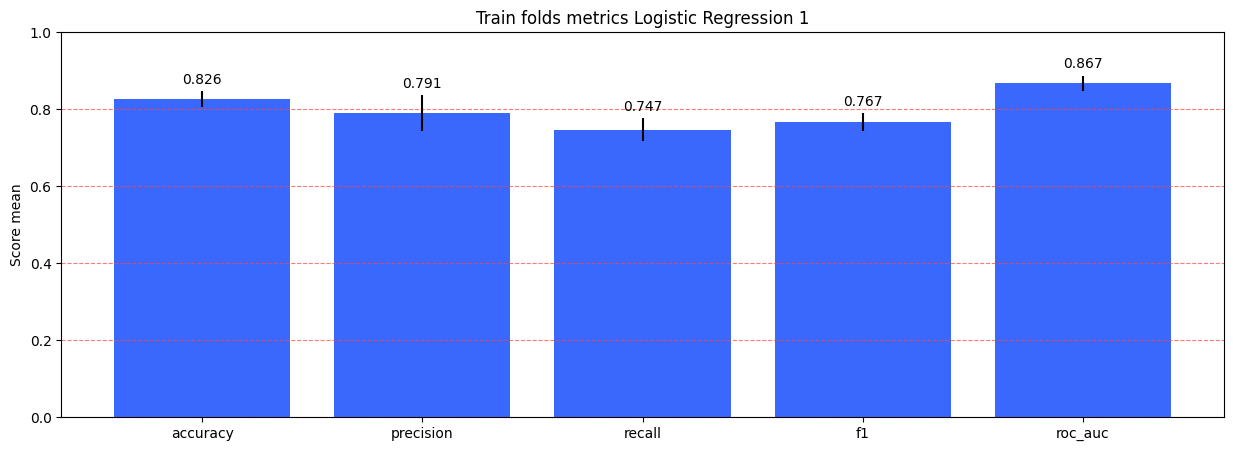

In [23]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,            # Poner de partida 5 barras
    means_logistic_1_folds,             # La altura de cada barra está dada por el valor de cada métrica
    yerr=stds_logistic_1_folds,         # Mostrar lo que puede variar cada barra
    color=SURVIVED_COLORS[1]
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])

ax.set_ylabel('Score mean')

ax.set_title('Train folds metrics Logistic Regression 1')

plt.savefig(MODEL_FIGURES_PATH / '01_train_metrics_logistic_regression_1.png', bbox_inches='tight')
plt.show()

### 7.1.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [24]:
logistic_1_pipeline.fit(X_train, y_train)

y_pred_logistic_1 = logistic_1_pipeline.predict(X_test)

Matriz de confusión

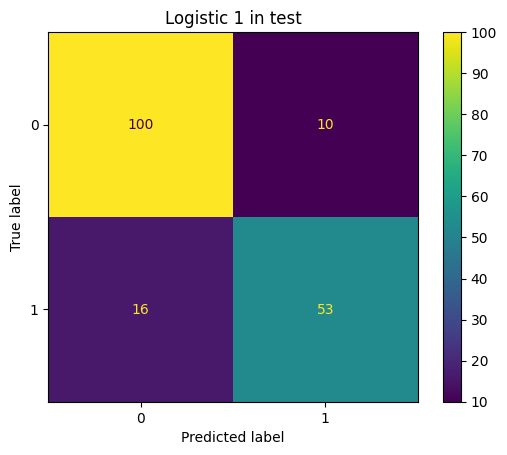

In [25]:
confusion_matrix_logistic_1 = confusion_matrix(y_test, y_pred_logistic_1)

display_confusion_matrix_logistic_1 = ConfusionMatrixDisplay(confusion_matrix_logistic_1)

display_confusion_matrix_logistic_1.plot()

plt.title('Logistic 1 in test')

plt.savefig(MODEL_FIGURES_PATH / '01_01_confusion_matrix_logistic_1')
plt.show()

## 7.2 Random Forest Classifier 1

### 7.2.1 Pipeline

In [26]:
random_forest_1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

### 7.2.2 Cross validate

In [27]:
results_random_forest_1_folds = cross_validate(
    random_forest_1_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [28]:
results_random_forest_1_folds

{'fit_time': array([0.21699357, 0.20630264, 0.20868278, 0.2099793 , 0.27767038]),
 'score_time': array([0.05285311, 0.05274343, 0.05351019, 0.07465363, 0.06587505]),
 'test_accuracy': array([0.7972028 , 0.79020979, 0.76760563, 0.82394366, 0.78873239]),
 'test_precision': array([0.74074074, 0.71929825, 0.71153846, 0.76363636, 0.75      ]),
 'test_recall': array([0.72727273, 0.74545455, 0.67272727, 0.77777778, 0.66666667]),
 'test_f1': array([0.73394495, 0.73214286, 0.69158879, 0.7706422 , 0.70588235]),
 'test_roc_auc': array([0.8447314 , 0.84989669, 0.88432602, 0.88731061, 0.86584596])}

In [29]:
mean_accuracy_random_forest_1_folds = np.mean(results_random_forest_1_folds['test_accuracy'])
mean_precision_random_forest_1_folds = np.mean(results_random_forest_1_folds['test_precision'])
mean_recall_random_forest_1_folds = np.mean(results_random_forest_1_folds['test_recall'])
mean_f1_random_forest_1_folds = np.mean(results_random_forest_1_folds['test_f1'])
mean_roc_auc_random_forest_1_folds = np.mean(results_random_forest_1_folds['test_roc_auc'])

In [30]:
std_accuracy_random_forest_1_folds = np.std(results_random_forest_1_folds['test_accuracy'])
std_precision_random_forest_1_folds = np.std(results_random_forest_1_folds['test_precision'])
std_recall_random_forest_1_folds = np.std(results_random_forest_1_folds['test_recall'])
std_f1_random_forest_1_folds = np.std(results_random_forest_1_folds['test_f1'])
std_roc_auc_random_forest_1_folds = np.std(results_random_forest_1_folds['test_roc_auc'])

In [31]:
means_random_forest_1_folds = [
    mean_accuracy_random_forest_1_folds,
    mean_precision_random_forest_1_folds,
    mean_recall_random_forest_1_folds,
    mean_f1_random_forest_1_folds,
    mean_roc_auc_random_forest_1_folds
]

In [32]:
stds_random_forest_1_fols = [
    std_accuracy_random_forest_1_folds,
    std_precision_random_forest_1_folds,
    std_recall_random_forest_1_folds,
    std_f1_random_forest_1_folds,
    std_roc_auc_random_forest_1_folds
]

### 7.2.3 Visualization

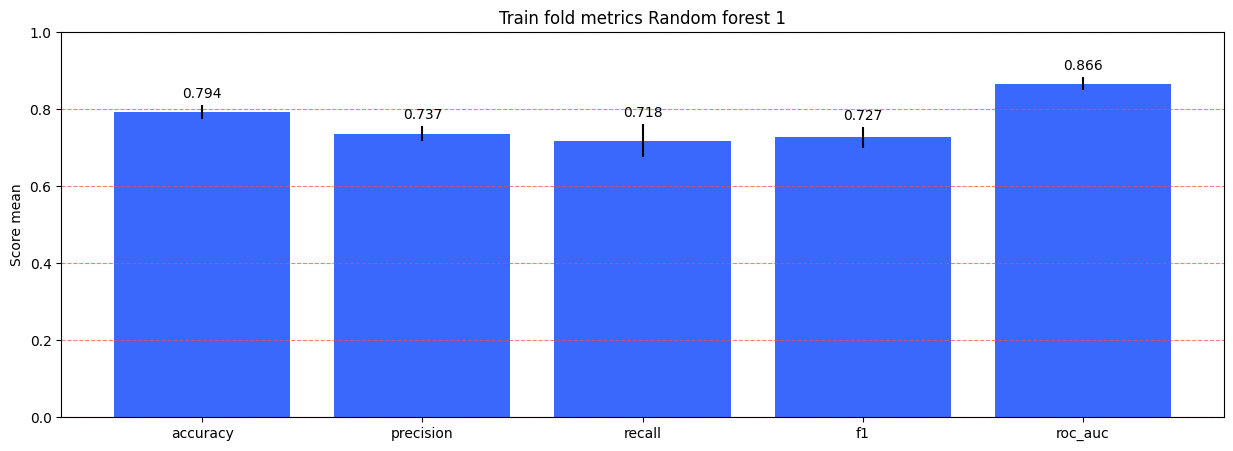

In [33]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_random_forest_1_folds,
    yerr=stds_random_forest_1_fols,
    color=SURVIVED_COLORS[1]
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics Random forest 1')


plt.savefig(MODEL_FIGURES_PATH / '02_train_metrics_random_forest_1', bbox_inches='tight')
plt.show()

### 7.2.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [34]:
random_forest_1_pipeline.fit(X_train, y_train)

y_pred_random_forest_1 = random_forest_1_pipeline.predict(X_test)

Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

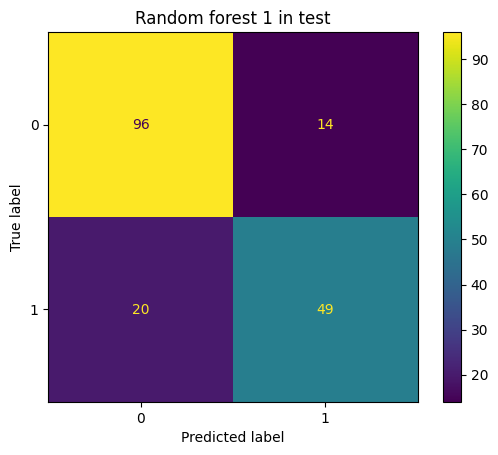

In [35]:
confusion_matrix_random_forest_1 = confusion_matrix(y_test, y_pred_random_forest_1)

display_confusion_matrix_random_forest_1 = ConfusionMatrixDisplay(confusion_matrix_random_forest_1)

display_confusion_matrix_random_forest_1.plot()

plt.title('Random forest 1 in test')

plt.savefig(MODEL_FIGURES_PATH / '02_01_confusion_matrix_random_forest_1')
plt.show

## 7.3 Decision Tree Classifier 1

### 7.3.1 Pipeline

In [36]:
decision_tree_1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier())
])

### 7.3.2 Cross validate

In [37]:
results_decision_tree_1_folds = cross_validate(
    decision_tree_1_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [38]:
results_decision_tree_1_folds

{'fit_time': array([0.02165198, 0.01575422, 0.01750374, 0.01533318, 0.01676416]),
 'score_time': array([0.03355169, 0.03313899, 0.02818942, 0.02760601, 0.0284164 ]),
 'test_accuracy': array([0.76923077, 0.79020979, 0.79577465, 0.76760563, 0.78169014]),
 'test_precision': array([0.68333333, 0.72727273, 0.76      , 0.6779661 , 0.7254902 ]),
 'test_recall': array([0.74545455, 0.72727273, 0.69090909, 0.74074074, 0.68518519]),
 'test_f1': array([0.71304348, 0.72727273, 0.72380952, 0.7079646 , 0.7047619 ]),
 'test_roc_auc': array([0.76714876, 0.78161157, 0.77575758, 0.76336279, 0.75831229])}

In [39]:
mean_accuracy_decision_tree_1_folds = np.mean(results_decision_tree_1_folds['test_accuracy'])
mean_precision_decision_tree_1_folds = np.mean(results_decision_tree_1_folds['test_precision'])
mean_recall_decision_tree_1_folds = np.mean(results_decision_tree_1_folds['test_recall'])
mean_f1_decision_tree_1_folds = np.mean(results_decision_tree_1_folds['test_f1'])
mean_roc_auc_decision_tree_1_folds = np.mean(results_decision_tree_1_folds['test_roc_auc'])

In [40]:
std_accuracy_decision_tree_1_folds = np.std(results_decision_tree_1_folds['test_accuracy'])
std_precision_decision_tree_1_folds = np.std(results_decision_tree_1_folds['test_precision'])
std_recall_decision_tree_1_folds = np.std(results_decision_tree_1_folds['test_recall'])
std_f1_decision_tree_1_folds = np.std(results_decision_tree_1_folds['test_f1'])
std_roc_auc_decision_tree_1_folds = np.std(results_decision_tree_1_folds['test_roc_auc'])

In [41]:
means_decision_tree_1_folds = [
    mean_accuracy_decision_tree_1_folds,
    mean_precision_decision_tree_1_folds,
    mean_recall_decision_tree_1_folds,
    mean_f1_decision_tree_1_folds,
    mean_roc_auc_decision_tree_1_folds
]

In [42]:
stds_decision_tree_1_fols = [
    std_accuracy_decision_tree_1_folds,
    std_precision_decision_tree_1_folds,
    std_recall_decision_tree_1_folds,
    std_f1_decision_tree_1_folds,
    std_roc_auc_decision_tree_1_folds
]

### 7.3.3 Visualization

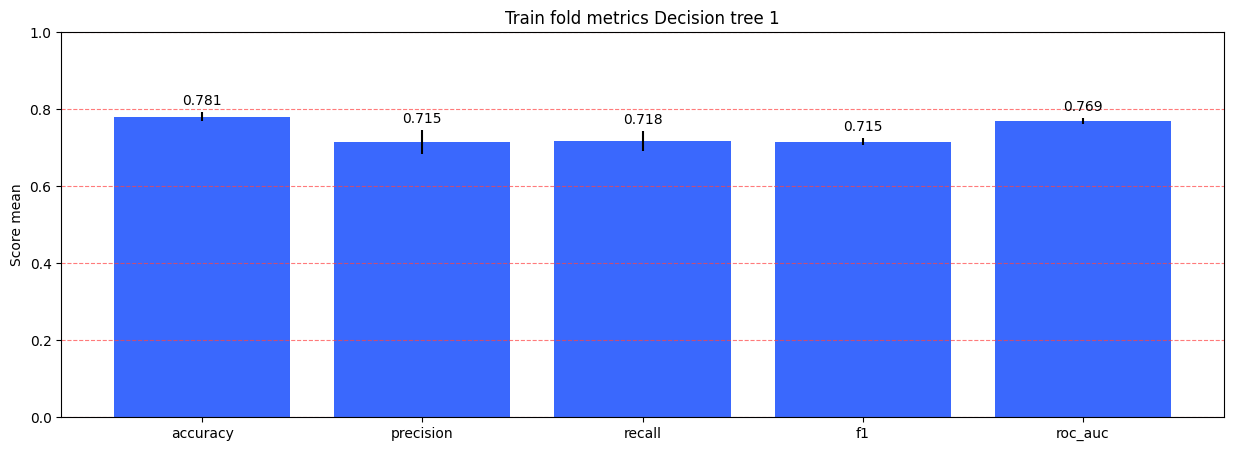

In [43]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_decision_tree_1_folds,
    yerr=stds_decision_tree_1_fols,
    color=SURVIVED_COLORS[1]
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics Decision tree 1')


plt.savefig(MODEL_FIGURES_PATH / '03_train_metrics_decision_tree_1', bbox_inches='tight')
plt.show()

### 7.3.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [44]:
decision_tree_1_pipeline.fit(X_train, y_train)

y_pred_decision_tree_1 = decision_tree_1_pipeline.predict(X_test)

Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

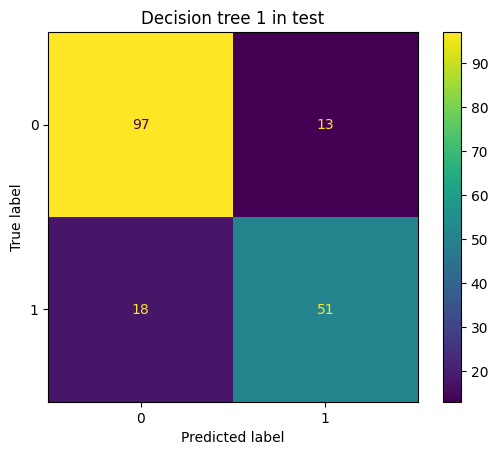

In [45]:
confusion_matrix_decision_tree_1 = confusion_matrix(y_test, y_pred_decision_tree_1)

display_confusion_matrix_decision_tree_1 = ConfusionMatrixDisplay(confusion_matrix_decision_tree_1)

display_confusion_matrix_decision_tree_1.plot()

plt.title('Decision tree 1 in test')

plt.savefig(MODEL_FIGURES_PATH / '03_01_confusion_matrix_decision_tree_1')
plt.show

## 7.4 KNN Classifier 1

### 7.4.1 Pipeline

In [46]:
knn_1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

### 7.4.2 Cross validate

In [47]:
results_knn_1_folds = cross_validate(
    knn_1_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=METRICS
)

In [48]:
results_knn_1_folds

{'fit_time': array([0.02546597, 0.01751494, 0.01889849, 0.01455331, 0.01990056]),
 'score_time': array([0.12908244, 0.03680158, 0.03743005, 0.04071093, 0.04057193]),
 'test_accuracy': array([0.8041958 , 0.79020979, 0.84507042, 0.82394366, 0.80985915]),
 'test_precision': array([0.75471698, 0.76595745, 0.85106383, 0.78431373, 0.81395349]),
 'test_recall': array([0.72727273, 0.65454545, 0.72727273, 0.74074074, 0.64814815]),
 'test_f1': array([0.74074074, 0.70588235, 0.78431373, 0.76190476, 0.72164948]),
 'test_roc_auc': array([0.83202479, 0.83429752, 0.89780564, 0.86363636, 0.82680976])}

In [49]:
mean_accuracy_knn_1_folds = np.mean(results_knn_1_folds['test_accuracy'])
mean_precision_knn_1_folds = np.mean(results_knn_1_folds['test_precision'])
mean_recall_knn_1_folds = np.mean(results_knn_1_folds['test_recall'])
mean_f1_knn_1_folds = np.mean(results_knn_1_folds['test_f1'])
mean_roc_auc_knn_1_folds = np.mean(results_knn_1_folds['test_roc_auc'])

In [50]:
std_accuracy_knn_1_folds = np.std(results_knn_1_folds['test_accuracy'])
std_precision_knn_1_folds = np.std(results_knn_1_folds['test_precision'])
std_recall_knn_1_folds = np.std(results_knn_1_folds['test_recall'])
std_f1_knn_1_folds = np.std(results_knn_1_folds['test_f1'])
std_roc_auc_knn_1_folds = np.std(results_knn_1_folds['test_roc_auc'])

In [51]:
means_knn_1_folds = [
    mean_accuracy_knn_1_folds,
    mean_precision_knn_1_folds,
    mean_recall_knn_1_folds,
    mean_f1_knn_1_folds,
    mean_roc_auc_knn_1_folds
]

In [52]:
stds_knn_1_fols = [
    std_accuracy_knn_1_folds,
    std_precision_knn_1_folds,
    std_recall_knn_1_folds,
    std_f1_knn_1_folds,
    std_roc_auc_knn_1_folds
]

### 7.4.3 Visualization

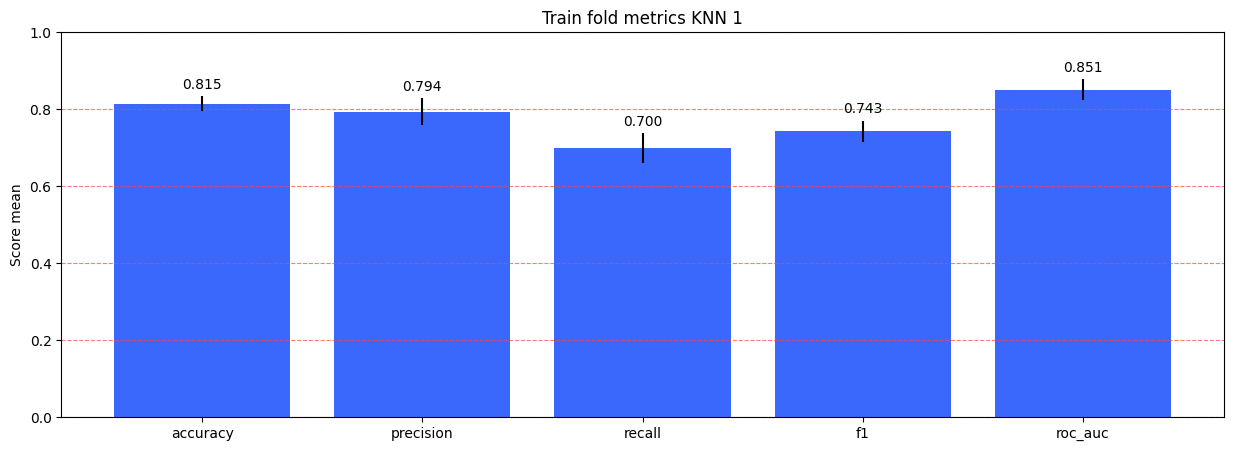

In [53]:
x_positions_to_bar_plot = np.arange(len(METRICS))

fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(
    x_positions_to_bar_plot,
    height=means_knn_1_folds,
    yerr=stds_knn_1_fols,
    color=SURVIVED_COLORS[1]
)

ax.bar_label(bars, fmt='%.3f', padding=3)

ax.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.7)

ax.set_xticks(x_positions_to_bar_plot)
ax.set_xticklabels(METRICS)

ax.set_ylim([0, 1])
ax.set_ylabel('Score mean')

ax.set_title('Train fold metrics KNN 1')


plt.savefig(MODEL_FIGURES_PATH / '04_train_metrics_knn_1', bbox_inches='tight')
plt.show()

### 7.4.4 Train and test

Probar el modelo con los datos de entrenamiento y ver como rinde en test

In [54]:
knn_1_pipeline.fit(X_train, y_train)

y_pred_knn_1 = knn_1_pipeline.predict(X_test)

Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

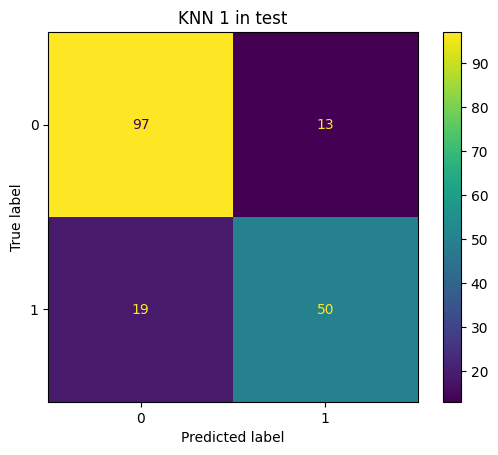

In [55]:
confusion_matrix_knn_1 = confusion_matrix(y_test, y_pred_knn_1)

display_confusion_matrix_knn_1 = ConfusionMatrixDisplay(confusion_matrix_knn_1)

display_confusion_matrix_knn_1.plot()

plt.title('KNN 1 in test')

plt.savefig(MODEL_FIGURES_PATH / '04_01_confusion_matrix_knn_1')
plt.show